# Python Script for Educational AI

In [5]:
#Import necesary modules to run the code
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
# import numdifftools as nd
   
from matplotlib import rc
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import math
import scipy
from scipy import integrate
from scipy import optimize
from scipy.misc import derivative
from scipy.optimize import fsolve

# from sympy import *  #check 
from sympy import exp, Symbol, nsolve

from numpy import sqrt, sin, cos, pi
import csv
import time

In [11]:
# pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [20]:
# Converting excel(.xlsx) file to more readable csv file
# Python Conversion Script
# You will need to install the openpyxl engine first: pip install pandas openpyxl.

import pandas as pd

# 1. Load the Excel file (.xlsx or .xls)
# Change 'input_file.xlsx' to your actual file name
# excel_data = pd.read_excel('input_file.xlsx')
excel_data = pd.read_excel(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert.xlsx")

# 2. Clean/Format (Optional)
# This removes empty rows and trailing whitespace from column names
excel_data.dropna(how='all', inplace=True)
excel_data.columns = excel_data.columns.str.strip()

# 3. Save as a clean CSV
# 'index=False' prevents Python from adding a new column of numbers (0, 1, 2...)
excel_data.to_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert_cleaned.csv", index=False, encoding='utf-8')

print("Conversion complete! Your readable CSV is ready.")

Conversion complete! Your readable CSV is ready.
   chp                                               name  Lectures  \
0  0.0                                     Prerequisites        1.0   
1  1.0                  Ch.1 – Stern-Gerlach Experiments        3.5   
2  2.0  Ch.2 – Rotation of Basis States / Matrix Mecha...       5.5   
3  3.0                           Ch.3 – Angular Momentum        5.0   
4  4.0                             Ch.4 – Time Evolution        5.0   
5  5.0             Ch.5 – System of 2 Spin-1/2 Particles        2.0   
6  6.0                       Ch.6 – Wave Mechanics in 1D        4.0   
7  7.0                                         Extraneous       1.0   
8  NaN                                                NaN      27.0   

   Formative  Summative         L         F         S  
0          5       0.00  0.037037  0.147059  0.000000  
1          6       9.33  0.129630  0.176471  0.291563  
2          5       5.97  0.203704  0.147059  0.186562  
3          5    

In [28]:
df = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert_cleaned.csv")
print(df)

   chp                                              name  Lectures  Formative  \
0    0                                    Prerequisites        1.0          5   
1    1                    Ch1 Stern-Gerlach Experiments        3.5          6   
2    2  Ch2 Rotation of Basis States / Matrix Mechanics        5.5          5   
3    3                             Ch3 Angular Momentum        5.0          5   
4    4                               Ch4 Time Evolution        5.0          7   
5    5               Ch5 System of 2 Spin-1/2 Particles        2.0          3   
6    6                         Ch6 Wave Mechanics in 1D        4.0          3   
7    7                                        Extraneous       1.0          0   

   Summative         L         F         S  
0       0.00  0.037037  0.147059  0.000000  
1       9.33  0.129630  0.176471  0.291563  
2       5.97  0.203704  0.147059  0.186562  
3       5.66  0.185185  0.147059  0.176875  
4       3.00  0.185185  0.205882  0.093750  


In [87]:
#Sample workflow 

import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Load the data
# Replace 'your_file.csv' with your actual filename
# df = pd.read_csv('your_file.csv')
df = pd.read_csv(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\Alignment_Chapters_Sievert_cleaned.csv")

# 2. Analyze the data
print("--- Statistical Summary ---")
print(df.describe())  # Shows mean, min, max, etc.

# Example: Calculate the mean of a specific column
# average_val = df['Column_Name'].mean()
# average_val = df['L'].mean()
# print(average_val)

# #Normalization (all)

# totL = df['Lectures'].sum()
# totF = df['Formative'].sum()
# totS = df['Summative'].sum() 

# print("total: {} Lectures, {} Formative, {} Summative".format(totL, totF, totS))


#Normalization (selected rows)

totL = df['Lectures'].iloc[1:6].sum()
totF = df['Formative'].iloc[1:6].sum()
totS = df['Summative'].iloc[1:6].sum() 

print("total: {} Lectures, {} Formative, {} Summative".format(totL, totF, totS))



# #Dot products: cosine alignment (all rows)

# L = df['L'] #Lecture
# LdotL = L * L
# totLdotL = LdotL.sum()
# print("Lectures/Lectures = {}, total Lectures/Lectures = {}".format(LdotL, totLdotL))

# F = df['F'] #Formative
# FdotF = F * F
# totFdotF = FdotF.sum()
# print("Formative/Formative = {}, total Formative/Formative = {}".format(FdotF, totFdotF))

# S = df['S'] #Summative
# SdotS = S * S
# totSdotS = SdotS.sum()
# print("Summative/Summative = {}, total Summative/Summative = {}".format(SdotS, totSdotS))


#Dot products: cosine alignment (selected rows)

L = df['L'] #Lecture
LdotL = L * L
totLdotL = LdotL.iloc[1:6].sum()
print("Lectures/Lectures = {}, total Lectures/Lectures = {}".format(LdotL, totLdotL))

F = df['F'] #Formative
FdotF = F * F
totFdotF = FdotF.iloc[1:6].sum()
print("Formative/Formative = {}, total Formative/Formative = {}".format(FdotF, totFdotF))

S = df['S'] #Summative
SdotS = S * S
totSdotS = SdotS.iloc[1:6].sum()
print("Summative/Summative = {}, total Summative/Summative = {}".format(SdotS, totSdotS))


LdotF = L * F
LdotS = L * S
FdotS = F * S


# # Sums values in rows 1 to 6 for the LdotF column (selected rows)

# totLdotF = LdotF.sum()
# totLdotS = LdotS.sum()
# totFdotS = FdotS.sum()


# Sums values in rows 1 to 6 for the LdotF column (selected rows)

totLdotF = LdotF.iloc[1:6].sum()
totLdotS = LdotS.iloc[1:6].sum()
totFdotS = FdotS.iloc[1:6].sum()



print("Lectures/Formative = {}, total Lectures/Formative = {}".format(LdotF, totLdotF))
print("Lectures/Summative = {}, total Lectures/Summative = {}".format(LdotS, totLdotS))
print("Formative/Summative = {}, total Formative/Summative = {}".format(FdotS, totFdotS))

# print("total: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totLdotF, totLdotS, totFdotS))


totalignLdotF = totLdotF / np.sqrt(totLdotL * totFdotF)
totalignLdotS = totLdotS / np.sqrt(totLdotL * totSdotS)
totalignFdotS = totFdotS / np.sqrt(totFdotF * totSdotS)

print("total alignment: Lectures/Formative = {}, Lectures/Summative = {}, Formative/Summative = {}".format(totalignLdotF, totalignLdotS, totalignFdotS))



--- Statistical Summary ---
           chp  Lectures  Formative  Summative         L         F         S
count  8.00000  8.000000   8.000000   8.000000  8.000000  8.000000  8.000000
mean   3.50000  3.375000   4.250000   3.998750  0.125000  0.125000  0.124961
std    2.44949  1.827371   2.187628   3.461921  0.067680  0.064342  0.108185
min    0.00000  1.000000   0.000000   0.000000  0.037037  0.000000  0.000000
25%    1.75000  1.750000   3.000000   0.900000  0.064815  0.088235  0.028125
50%    3.50000  3.750000   5.000000   4.330000  0.138889  0.147059  0.135313
75%    5.25000  5.000000   5.250000   6.185000  0.185185  0.154412  0.193281
max    7.00000  5.500000   7.000000   9.330000  0.203704  0.205882  0.291563
total: 21.0 Lectures, 26 Formative, 25.16 Summative
Lectures/Lectures = 0    0.001372
1    0.016804
2    0.041495
3    0.034294
4    0.034294
5    0.005487
6    0.021948
7    0.001372
Name: L, dtype: float64, total Lectures/Lectures = 0.13237311392318246
Formative/Formative = 0 

In [ ]:
#Plot data from Excel (.csv) file
#Sievert_2024 

# # 3. Plot the data
# plt.figure(figsize=(10, 6))

# # Example: A simple line plot
# # Replace 'X_Axis_Column' and 'Y_Axis_Column' with your actual headers
# plt.plot(df['X_Axis_Column'], df['Y_Axis_Column'], marker='o', linestyle='-', color='b', label='Data Trend')

# # Customizing the chart
# plt.title('Data Analysis Results')
# plt.xlabel('X-Axis Label')
# plt.ylabel('Y-Axis Label')
# plt.legend()
# plt.grid(True)

# # Display the plot
# plt.show()


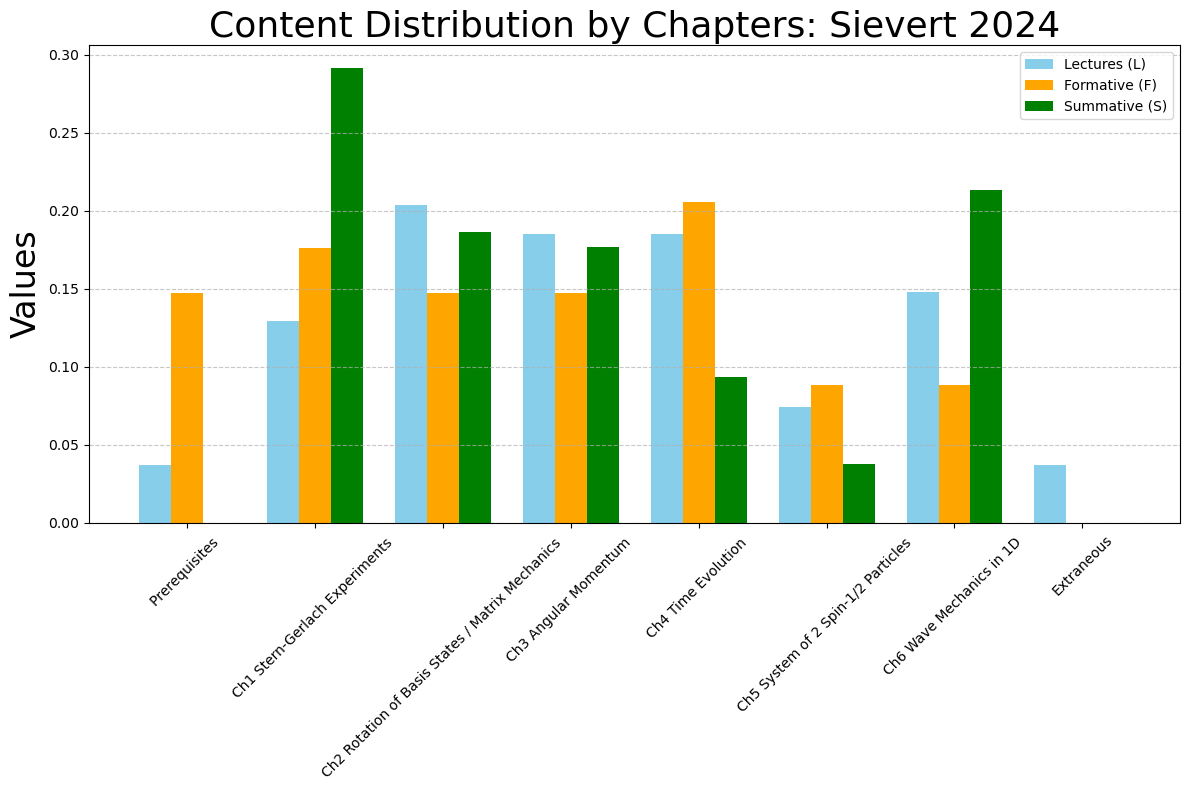

In [91]:
import matplotlib.pyplot as plt
import numpy as np

#PlotA: Content distribution by chapter (2D column plot): all rows


# 1. Setup data (all data)
chapters = df['name'] # Or df.index if chapters aren't a column
x = np.arange(len(chapters))  # Label locations
width = 0.25  # Width of the bars

# # 1. Slice your data to match your analysis (Rows 1 to 5)
# # Using 1:6 to match your .iloc[1:6] logic from the previous step
# subset_df = df.iloc[1:6] 
# chapters = subset_df['name'] # Ensure 'Chapter' is the name of your column
# x = np.arange(len(chapters))     # Create index positions (0, 1, 2...)
# width = 0.25 

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8))


# Offset each category by the width so they stand side-by-side
rects1 = ax.bar(x - width, df['L'], width, label='Lectures (L)', color='skyblue')
rects2 = ax.bar(x, df['F'], width, label='Formative (F)', color='orange')
rects3 = ax.bar(x + width, df['S'], width, label='Summative (S)', color='green')

# 3. Add labels and formatting
# ax.set_xlabel('Chapters', fontsize=24)
ax.set_ylabel('Values', fontsize=24)
ax.set_title('Content Distribution by Chapters: Sievert 2024', fontsize=26)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45)
ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2024_ch1to6.png", bbox_inches='tight')
# plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2024_all.png", bbox_inches='tight')
plt.show()


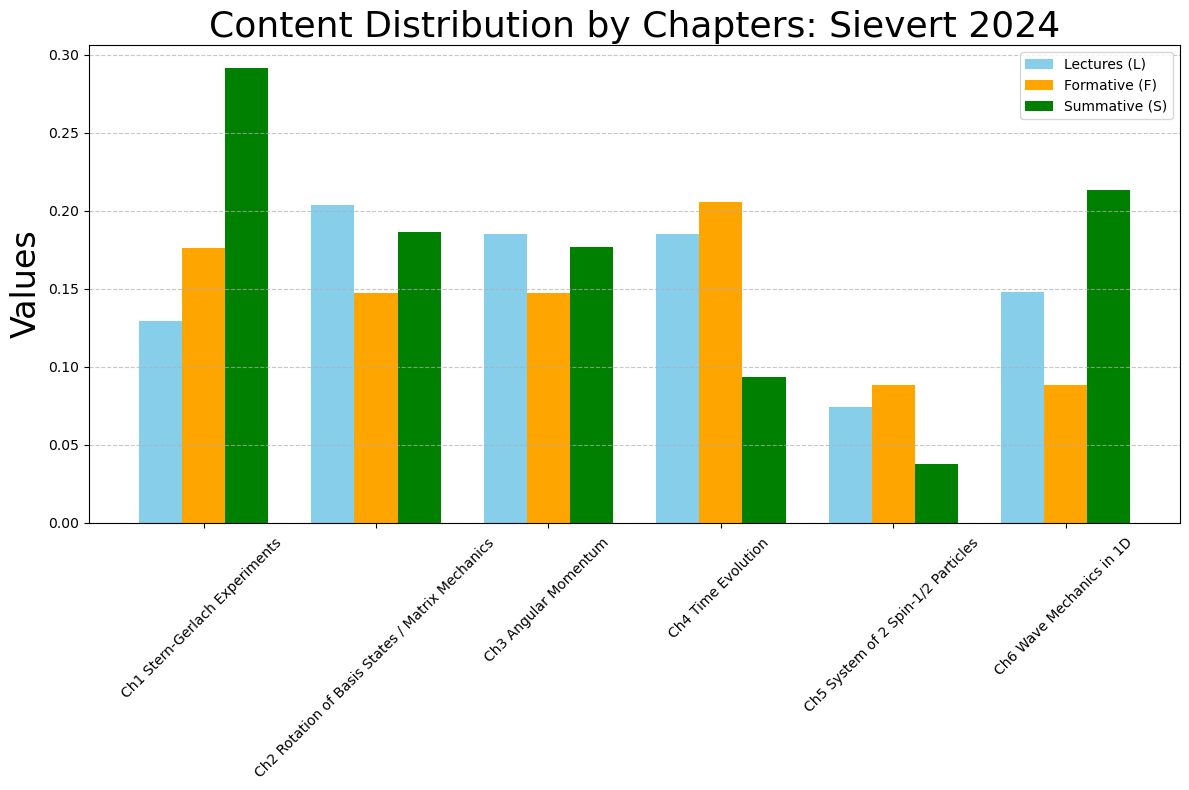

In [101]:
# 1. Select the rows first so everything is the same size (5 rows)
subset_df = df.iloc[1:7] 
chapters = subset_df['name']

# 2. Create 'x' based on the 5 rows in the subset
x = np.arange(len(subset_df)) 
width = 0.25

fig, ax = plt.subplots(figsize=(12, 8))

# 3. Plot using ONLY the subset data
# Use subset_df instead of the original df
ax.bar(x - width, subset_df['L'], width, label='Lectures (L)', color='skyblue')
ax.bar(x,         subset_df['F'], width, label='Formative (F)', color='orange')
ax.bar(x + width, subset_df['S'], width, label='Summative (S)', color='green')

# 4. Set the labels using the subset chapter names
# Add labels and formatting
# ax.set_xlabel('Chapters', fontsize=24)
ax.set_ylabel('Values', fontsize=24)
ax.set_title('Content Distribution by Chapters: Sievert 2024', fontsize=26)
ax.set_xticks(x)
ax.set_xticklabels(chapters, rotation=45)
ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\content_dist_by_chapters_Sievert_2024_ch1to6.png", bbox_inches='tight')
plt.show()


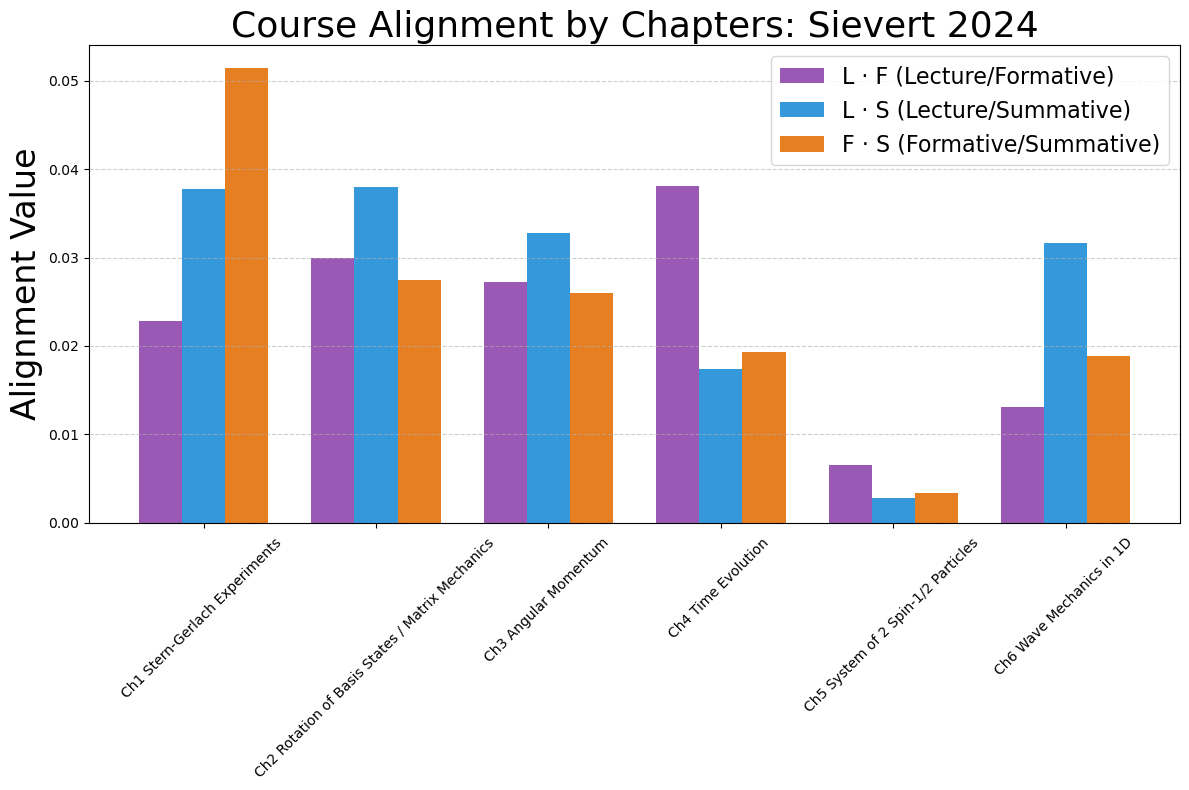

In [115]:
#Plot B: Course Alignment by Chapter: Sievert

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Slice the 6 chapters without pre and extra (Index 1 to 7)
subset = df.iloc[1:7].copy()

# 2. Calculate the dot products per chapter
subset['LdotF'] = subset['L'] * subset['F']
subset['LdotS'] = subset['L'] * subset['S']
subset['FdotS'] = subset['F'] * subset['S']

# 3. Setup the plot positions
x = np.arange(len(subset))  # Length is 6
width = 0.25 

fig, ax = plt.subplots(figsize=(12, 8))

# 4. Plot the 3 dot product categories
rects1 = ax.bar(x - width, subset['LdotF'], width, label='L · F (Lecture/Formative)', color='#9b59b6') # Purple
rects2 = ax.bar(x,         subset['LdotS'], width, label='L · S (Lecture/Summative)', color='#3498db') # Blue
rects3 = ax.bar(x + width, subset['FdotS'], width, label='F · S (Formative/Summative)', color='#e67e22') # Orange

# 5. Formatting
# ax.set_xlabel('Chapters')
ax.set_ylabel('Alignment Value', fontsize=24)
ax.set_title('Course Alignment by Chapters: Sievert 2024', fontsize=26)
ax.set_xticks(x)
ax.set_xticklabels(subset['name'], rotation=45)
ax.legend(fontsize=16)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

# Save the plot (using double quotes for the path with an apostrophe)
save_path = r"C:\Users\Hasan's PC\OneDrive - New Mexico State University\Desktop\Educational AI\Resources\Python_Script\course_alignment_by_chapters_Sievert_2024_ch1to6.png.png"
plt.savefig(save_path, bbox_inches='tight')

plt.show()
